Лабораторная работа №1

Выпонил: Ковалев Руслан Бабекович || 466200 || K3242

Численные Методы Моделирования

Подключаем библиотеки:


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm
np.set_printoptions(precision=4, suppress=True)

1. Точные методы решения СЛАУ

1.1 Метод Гаусса с частичным выбором главного элемента

Теория

Метод Гаусса используется для приведения матрицы системы к верхнетреугольному виду. Частичный выбор главного элемнта повышает численную устойчивость метода за счёт перестановки строк.

In [20]:
def gauss_partial_pivot(A, b):
    A = A.astype(float).copy()
    b = b.astype(float).copy()
    n = len(b)


    for k in range(n - 1):
        p = np.argmax(np.abs(A[k:, k])) + k
        if p != k:
            A[[k, p]] = A[[p, k]]
            b[[k, p]] = b[[p, k]]
        for i in range(k + 1, n):
            m = A[i, k] / A[k, k]
            A[i, k:] -= m * A[k, k:]
            b[i] -= m * b[k]


    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - A[i, i + 1:] @ x[i + 1:]) / A[i, i]
    return x

Теперь проверим корректность

In [21]:
for n in [10, 50]:
    A = np.random.randn(n, n)
    b = np.random.randn(n)
    x = gauss_partial_pivot(A, b)
    print(f"n={n}, ||Ax-b|| = {norm(A @ x - b):.2e}")

n=10, ||Ax-b|| = 2.27e-15
n=50, ||Ax-b|| = 1.88e-14


1.2 LU-разложение

Теория

LU-разложение представляет матрицу в виде произведения нижней и верхней треугольных матриц: A = LU.

In [22]:
def lu_decomposition(A):
    A = A.astype(float)
    n = A.shape[0]
    L = np.eye(n)
    U = A.copy()

    for k in range(n - 1):
        for i in range(k + 1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i, k:] -= L[i, k] * U[k, k:]
    return L, U

def lu_solve(L, U, b):
    n = len(b)
    y = np.zeros(n)
    for i in range(n):
        y[i] = b[i] - L[i, :i] @ y[:i]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - U[i, i + 1:] @ x[i + 1:]) / U[i, i]
    return x


# Проверка корректности 
n = 10
A = np.random.randn(n, n)
b = np.random.randn(n)

L, U = lu_decomposition(A)
x = lu_solve(L, U, b)

print("LU: ||Ax - b|| =", norm(A @ x - b))


LU: ||Ax - b|| = 3.0520170910854146e-15


1.3 Разложение Холецкого

Теория

Для симметричных положительно определённых матриц существует разложение A = LLᵀ.

In [23]:
def cholesky_decomposition(A):
    n = A.shape[0]
    L = np.zeros_like(A)
    for i in range(n):
        for j in range(i + 1):
            s = sum(L[i, k] * L[j, k] for k in range(j))
            if i == j:
                L[i, j] = np.sqrt(A[i, i] - s)
            else:
                L[i, j] = (A[i, j] - s) / L[j, j]
    return L

# Проверка корректности разложения Холецкого
n = 10
B = np.random.randn(n, n)
A = B.T @ B + n * np.eye(n)   # симметричная положительно определённая матрица
b = np.random.randn(n)

L = cholesky_decomposition(A)

y = np.linalg.solve(L, b)
x = np.linalg.solve(L.T, y)

print("Cholesky: ||Ax - b|| =", norm(A @ x - b))


Cholesky: ||Ax - b|| = 5.861620100950614e-16


2. Итерационные методы решения СЛАУ

2.1 Метод Якоби

In [24]:
def jacobi(A, b, x0, tol=1e-8, max_iter=10000):
    n = len(b)
    x = x0.copy()
    D = np.diag(A)
    R = A - np.diagflat(D)
    history = []
    for k in range(max_iter):
        x_new = (b - R @ x) / D
        history.append(norm(A @ x_new - b))
        if history[-1] < tol:
            break
        x = x_new
    return x, history

2.2 Метод Гаусса–Зейделя

In [25]:
def gauss_seidel(A, b, x0, tol=1e-8, max_iter=10000):
    n = len(b)
    x = x0.copy()
    history = []
    for k in range(max_iter):
        for i in range(n):
            s1 = A[i, :i] @ x[:i]
            s2 = A[i, i + 1:] @ x[i + 1:]
            x[i] = (b[i] - s1 - s2) / A[i, i]
        history.append(norm(A @ x - b))
        if history[-1] < tol:
            break
    return x, history

Сравнение сходимости

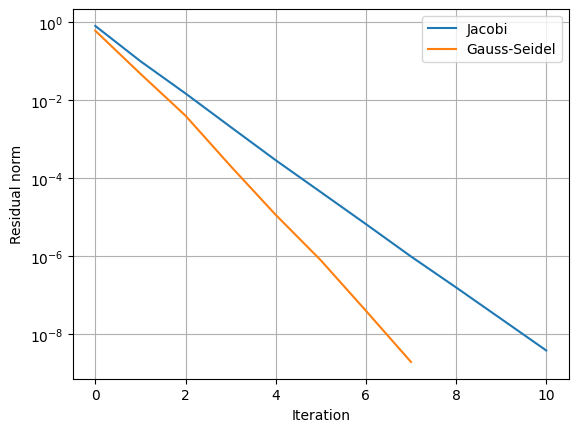

In [26]:
n = 50
A = np.random.randn(n, n)
A += n * np.eye(n)
b = np.random.randn(n)
x0 = np.zeros(n)


x_j, hist_j = jacobi(A, b, x0)
x_gs, hist_gs = gauss_seidel(A, b, x0)


plt.semilogy(hist_j, label='Jacobi')
plt.semilogy(hist_gs, label='Gauss-Seidel')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Residual norm')
plt.grid()
plt.show()

3. Нелинейные уравнения (одномерный случай)

3.1 Реализация методов

In [27]:
def newton(f, df, x0, tol=1e-10, max_iter=100):
    x = x0
    history = []
    for _ in range(max_iter):
        x = x - f(x) / df(x)
        history.append(abs(f(x)))
        if history[-1] < tol:
            break
    return x, history

def secant(f, x0, x1, tol=1e-10, max_iter=100):
    history = []
    for _ in range(max_iter):
        x2 = x1 - f(x1) * (x1 - x0) / (f(x1) - f(x0))
        x0, x1 = x1, x2
        history.append(abs(f(x1)))
        if history[-1] < tol:
            break
    return x1, history

def fixed_tangent(f, df, x0, tol=1e-10, max_iter=100):
    x = x0
    df0 = df(x0)
    history = []
    for _ in range(max_iter):
        x = x - f(x) / df0
        history.append(abs(f(x)))
        if history[-1] < tol:
            break
    return x, history

3.2 Численные эксперименты

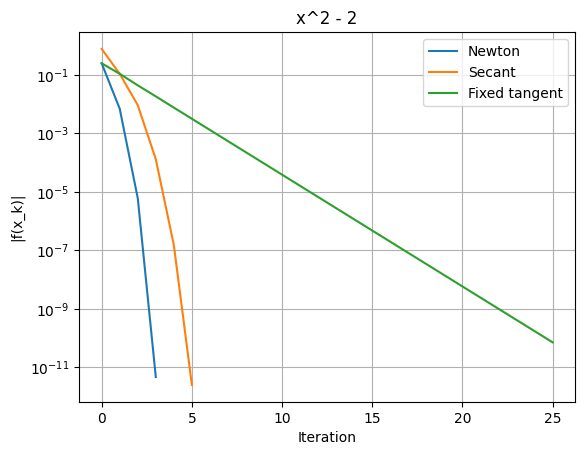

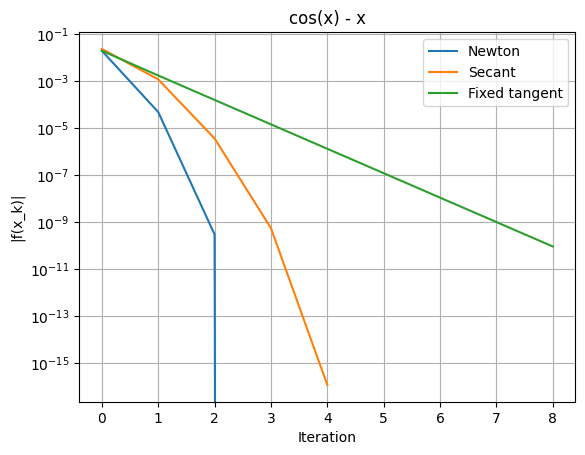

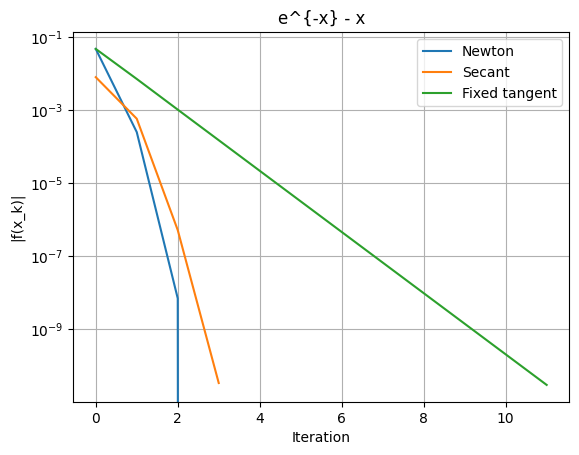

In [28]:
functions = [
    (lambda x: x**2 - 2, lambda x: 2*x, 'x^2 - 2'),
    (lambda x: np.cos(x) - x, lambda x: -np.sin(x) - 1, 'cos(x) - x'),
    (lambda x: np.exp(-x) - x, lambda x: -np.exp(-x) - 1, 'e^{-x} - x')
]


for f, df, name in functions:
    _, h1 = newton(f, df, 1.0)
    _, h2 = secant(f, 0.5, 1.0)
    _, h3 = fixed_tangent(f, df, 1.0)


    plt.semilogy(h1, label='Newton')
    plt.semilogy(h2, label='Secant')
    plt.semilogy(h3, label='Fixed tangent')
    plt.title(name)
    plt.xlabel('Iteration')
    plt.ylabel('|f(x_k)|')
    plt.legend()
    plt.grid()
    plt.show()